# P1 · 05 — Forecasting *annual* GDP end-to-end (small-sample edition)

So far we've worked the quarterly series. The **annual** real GDP series (1960–2024,
~65 points, *no seasonality*) is a different challenge: a longer span but far fewer
points, dominated by a single exponential trend. It's the classic macro
"small-data" forecast — and a stress test for our workflow.

We run the **same disciplined pipeline** at this new frequency:
transform → baselines → ETS/ARIMA/Theta → backtest → forecast with intervals.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))   # repo root
warnings.filterwarnings("ignore")
try:  # silence statsmodels' chatty (harmless) convergence / lookup warnings
    from statsmodels.tools.sm_exceptions import (
        ConvergenceWarning, InterpolationWarning, ValueWarning)
    for _w in (ConvergenceWarning, InterpolationWarning, ValueWarning):
        warnings.simplefilter("ignore", _w)
except Exception:
    pass
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import data, plots
plots.setup()

from src import baselines as B, backtest as bt, classical as C
annual = data.load_annual()
la = np.log(annual)
print("annual:", annual.index.min(), "->", annual.index.max(), "| n =", len(annual))

annual: 1960 -> 2024 | n = 65


### No seasonality → simpler models

Annual data has no within-year cycle, so the seasonal machinery (Holt-Winters'
seasonal term, SARIMA's seasonal orders) is irrelevant. The right tools are:

* **Holt's linear trend** (ETS with trend, no seasonal),
* **ARIMA(p,1,q)** on the log (one difference removes the trend),
* **Theta** (a strong, cheap benchmark; `period=1` → non-seasonal).

The baselines simplify too: `seasonal_naive` collapses to `naive`, so we use
`naive`, `drift`, `mean`. MASE uses `season_length=1` (the random-walk scale).

In [2]:
fcs = {
    "naive": B.naive,
    "drift": B.drift,
    "mean":  B.mean,
    "Holt":  C.ets_forecaster(trend="add", seasonal=None),
    "ARIMA(1,1,1)": C.sarima_forecaster((1, 1, 1), (0, 0, 0, 0)),
    "Theta": C.theta_forecaster(period=1),
}
board = bt.compare(annual, fcs, initial=45, h=3, step=1, season_length=1)
board.round(3)

,MAE,RMSE,MAPE,sMAPE,MASE
Holt,4.685170e+12,7.644624e+12,3.628,3.564,1.503
"ARIMA(1,1,1)",4.725562e+12,8.302771e+12,3.689,3.548,1.516
Theta,8.665528e+12,1.043195e+13,7.639,7.999,2.780
drift,9.846700e+12,1.197725e+13,8.615,9.097,3.159
naive,1.300125e+13,1.533348e+13,11.465,12.329,4.170
mean,8.162475e+13,8.612575e+13,71.682,111.898,26.183


> **Reading MASE at multi-step horizons.** Notice *every* model shows MASE > 1.
> That is **expected**, not alarming: the MASE denominator is the **one-step**
> in-sample naive error, but we're forecasting **3 years** ahead — a much harder
> task. So here, judge models by **ranking**, not the 1.0 line: Holt/ARIMA cut the
> error to roughly **a third** of the `naive` row. The absolute "< 1 beats naive"
> rule is exact only for one-step forecasts.

### Forecast the next 6 years with an interval

We take the backtest winner (typically **Holt** or **ARIMA**) and forecast on the
log scale, exponentiating the mean and the 95% band (so the band is asymmetric in
levels — correct for multiplicative growth).

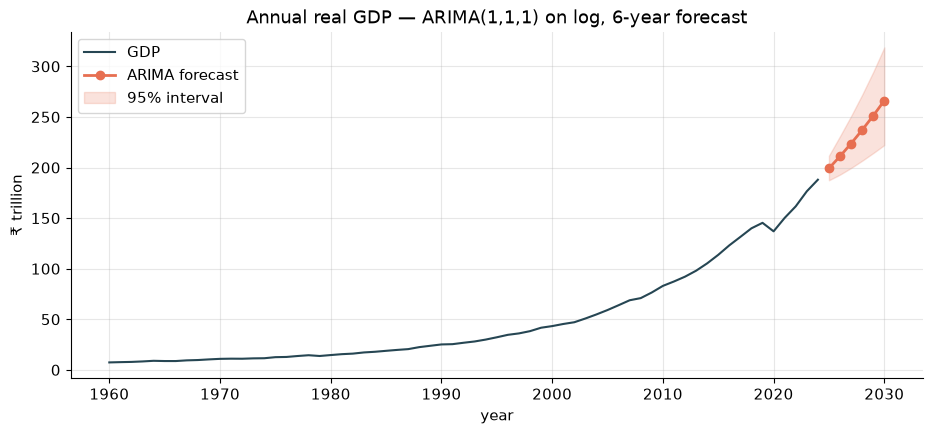

Forecast implied annual growth (%): [5.81 5.81 5.8  5.79 5.79 5.78]


In [3]:
from statsmodels.tsa.arima.model import ARIMA
H = 6
m = ARIMA(la.to_numpy(), order=(1, 1, 1)).fit()
fcres = m.get_forecast(H)
mean = np.exp(fcres.predicted_mean)
ci = np.exp(fcres.conf_int(alpha=0.05))
yrs = np.arange(annual.index.max() + 1, annual.index.max() + 1 + H)

fig, ax = plt.subplots()
ax.plot(annual.index, annual.values / 1e12, color="#264653", label="GDP")
ax.plot(yrs, mean / 1e12, color="#e76f51", lw=2, marker="o", label="ARIMA forecast")
ax.fill_between(yrs, ci[:, 0] / 1e12, ci[:, 1] / 1e12, color="#e76f51",
                alpha=0.2, label="95% interval")
ax.set(title="Annual real GDP — ARIMA(1,1,1) on log, 6-year forecast",
       xlabel="year", ylabel="₹ trillion"); ax.legend(); plt.show()

implied = (np.diff(np.log(np.r_[annual.values[-1], mean])) * 100)
print("Forecast implied annual growth (%):", np.round(implied, 2))

The implied growth should sit near the historical **~6%** mean — a sanity check that
the model is extrapolating the real trend, not inventing one.

**Takeaway:** the workflow is *frequency-agnostic*. With only ~65 points, lean
models (Holt, low-order ARIMA, Theta) dominate — there simply isn't data to support
anything fancier. Small samples reward restraint.

---
**Next (06):** two more classical approaches — **Prophet** and the **Theta method** —
on the quarterly series.